<a href="https://colab.research.google.com/github/maggie20041027-svg/ECON3916-Statistical-Machine-Learning/blob/main/Assignment%201%20Revised/%20Econ_3916_Assignment_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
# Manual Data Construction
student_basket = [
    {'Item': 'Tuition', 'Price_2016': 45000, 'Price_2024': 58000},
    {'Item': 'Rent (1 Bed)', 'Price_2016': 1200, 'Price_2024': 1800},
    {'Item': 'Chipotle Burrito', 'Price_2016': 7.50, 'Price_2024': 11.50},
    {'Item': 'Spotify', 'Price_2016': 9.99, 'Price_2024': 11.99},
]

In [18]:
# Calculate the inflation rates
def calculate_inflation(Price_2016, Price_2024):
    return ((Price_2024 - Price_2016) / Price_2016) * 100

# For loop
for item in student_basket:
    rate = calculate_inflation(item['Price_2016'], item['Price_2024'])
    print(f"{item['Item']}: {rate:.2f}% Inflation")

Tuition: 28.89% Inflation
Rent (1 Bed): 50.00% Inflation
Chipotle Burrito: 53.33% Inflation
Spotify: 20.02% Inflation


In [19]:
!pip install fredapi

import pandas as pd
from fredapi import Fred
fred = Fred(api_key='42636bb70ea4335cdcffbfbd82d831fe')

# Fetch Series
official_cpi = fred.get_series('CPIAUCSL')
tuition = fred.get_series('CUSR0000SEEB') # Added Tuition
rent = fred.get_series('CUSR0000SEHA') # Added Rent
chipotle = fred.get_series('CUSR0000SEFV') # Added Chipotle
spotify = fred.get_series('CUSR0000SERA02') # Added Spotify

In [20]:
# Combine series into dataframe
df = pd.DataFrame({
    'Official_CPI': official_cpi,
    'Tuition': tuition,
    'Rent': rent,
    'Chipotle': chipotle,
    'Spotify': spotify
})

In [21]:
# Drop any missing values
df = df.dropna()

In [22]:
# Apply formula to every row in the dataframe
start_date = '2016-01-01'
Value_Index = (df / df.loc[start_date]) * 100

# CRITICAL FIX: Save normalized values back to df
df['Official_CPI'] = Value_Index['Official_CPI']
df['Tuition'] = Value_Index['Tuition']
df['Rent'] = Value_Index['Rent']
df['Chipotle'] = Value_Index['Chipotle']
df['Spotify'] = Value_Index['Spotify']

# Check
print('2016 Normalized Data:')
print(Value_Index.loc['2016-01-01'])
print('How much did things increase from 2016 to 2024?')
print(Value_Index.loc['2024-01-01'])

2016 Normalized Data:
Official_CPI    100.0
Tuition         100.0
Rent            100.0
Chipotle        100.0
Spotify         100.0
Name: 2016-01-01 00:00:00, dtype: float64
How much did things increase from 2016 to 2024?
Official_CPI    130.315756
Tuition         121.235377
Rent            141.103874
Chipotle        139.733726
Spotify         135.598005
Name: 2024-01-01 00:00:00, dtype: float64


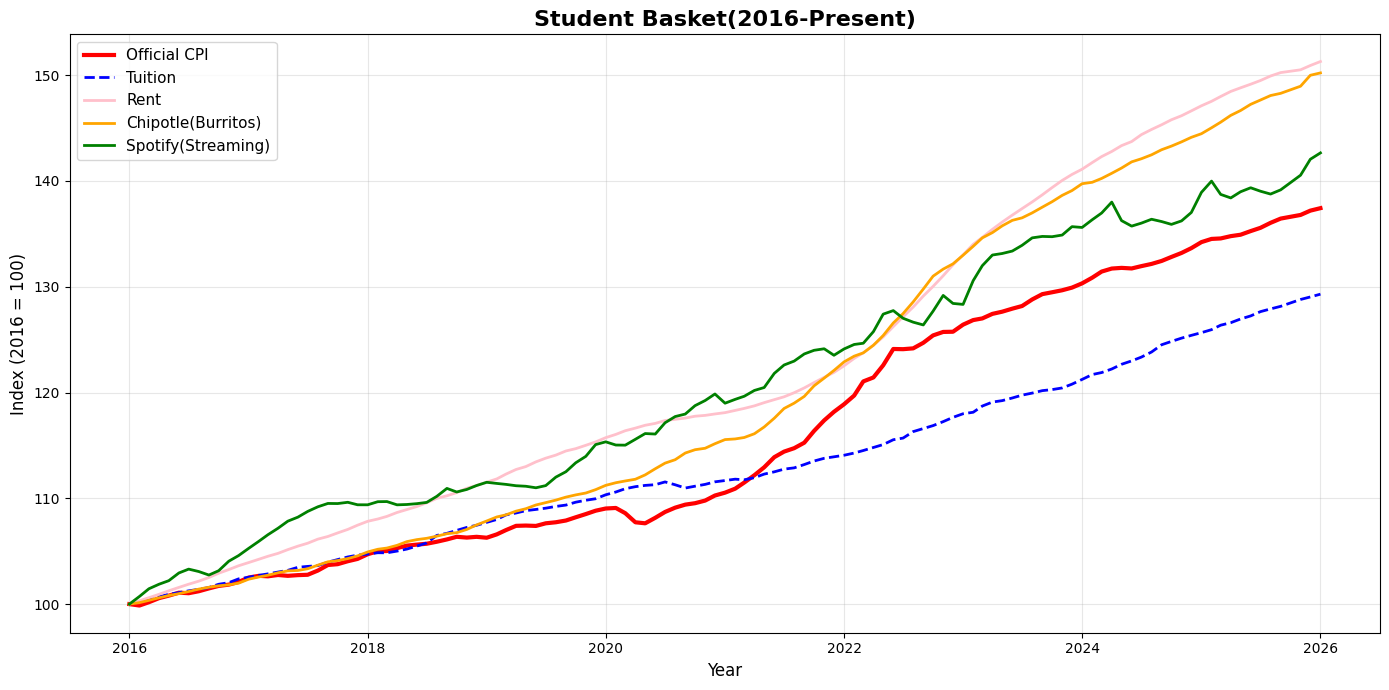

In [31]:
import matplotlib.pyplot as plt

# Filter to 2016 onwards
plot_data = Value_Index.loc['2016-01-01':]

# Create figure and axis
fig, ax = plt.subplots(figsize=(14, 7))

# Plot all the normalized series
ax.plot(plot_data.index, plot_data['Official_CPI'],
        linestyle='-', color='red', linewidth=3, label='Official CPI')

ax.plot(plot_data.index, plot_data['Tuition'],
        linestyle='--', color='blue', linewidth=2, label='Tuition')

ax.plot(plot_data.index, plot_data['Rent'],
        linestyle='-', color='pink', linewidth=2, label='Rent')

ax.plot(plot_data.index, plot_data['Chipotle'],
        linestyle='-', color='orange', linewidth=2, label='Chipotle(Burritos)')

ax.plot(plot_data.index, plot_data['Spotify'],
        linestyle='-', color='green', linewidth=2, label='Spotify(Streaming)')

ax.set_title('Student Basket(2016-Present)', fontsize=16, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Index (2016 = 100)', fontsize=12)
ax.legend(loc='best', fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [24]:
# Assign weights
weights = {
    'Tuition': 0.5,
    'Rent': 0.4,
    'Chipotle': 0.05,
    'Spotify': 0.05
}

In [25]:
df['Student_SPI'] = (
    df['Tuition'] * weights['Tuition'] +
    df['Rent'] * weights['Rent'] +
    df['Chipotle'] * weights['Chipotle'] +
    df['Spotify'] * weights['Spotify']
)

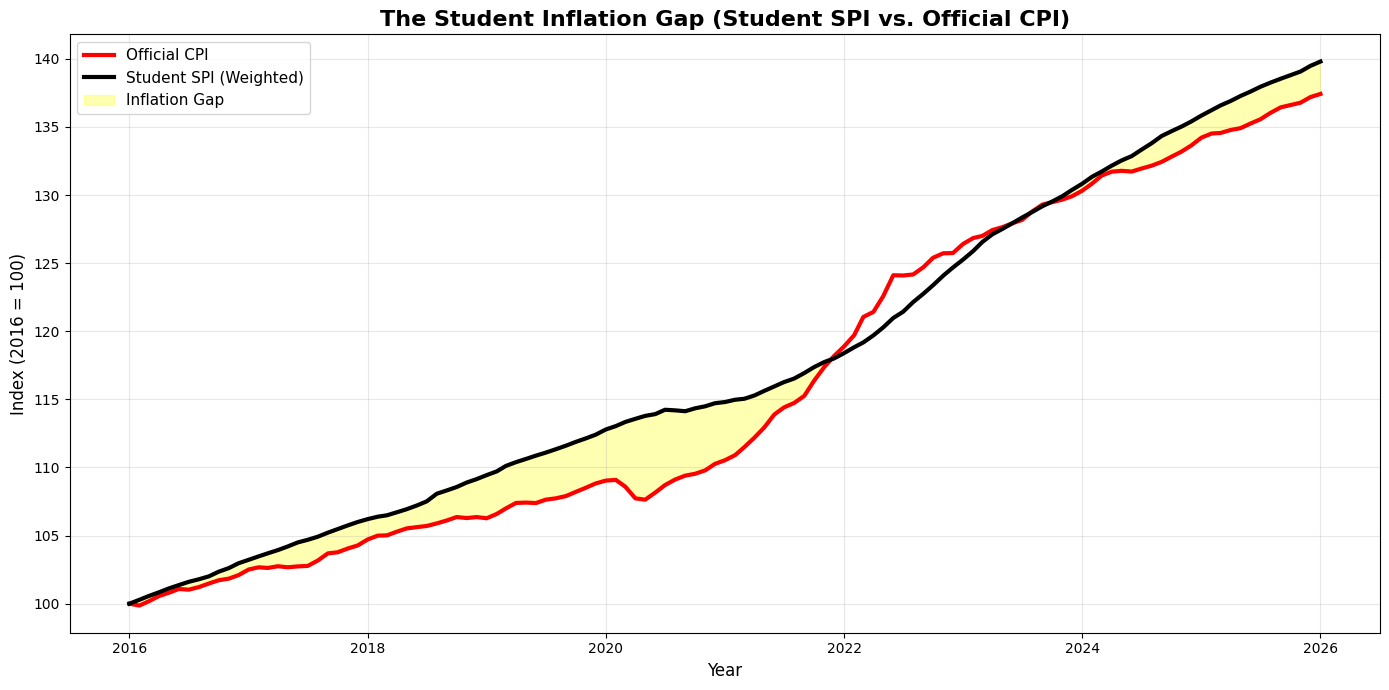

In [32]:
# Filter to 2016 onwards
start = '2016-01-01'

fig, ax = plt.subplots(figsize=(14, 7))

# Plot the Official CPI
ax.plot(Value_Index.loc[start:].index, Value_Index.loc[start:]['Official_CPI'],
        color='red', linewidth=3, label='Official CPI')

# Plot the Student SPI
ax.plot(df.loc[start:].index, df.loc[start:]['Student_SPI'],
        color='black', linewidth=3, label='Student SPI (Weighted)')

# Fill and highlight the gap
ax.fill_between(df.loc[start:].index,
                Value_Index.loc[start:]['Official_CPI'],
                df.loc[start:]['Student_SPI'],
                where=(df.loc[start:]['Student_SPI'] >= Value_Index.loc[start:]['Official_CPI']),
                color='yellow', alpha=0.3, label='Inflation Gap')

ax.set_title('The Student Inflation Gap (Student SPI vs. Official CPI)', fontsize=16, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Index (2016 = 100)', fontsize=12)
ax.legend(loc='best', fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

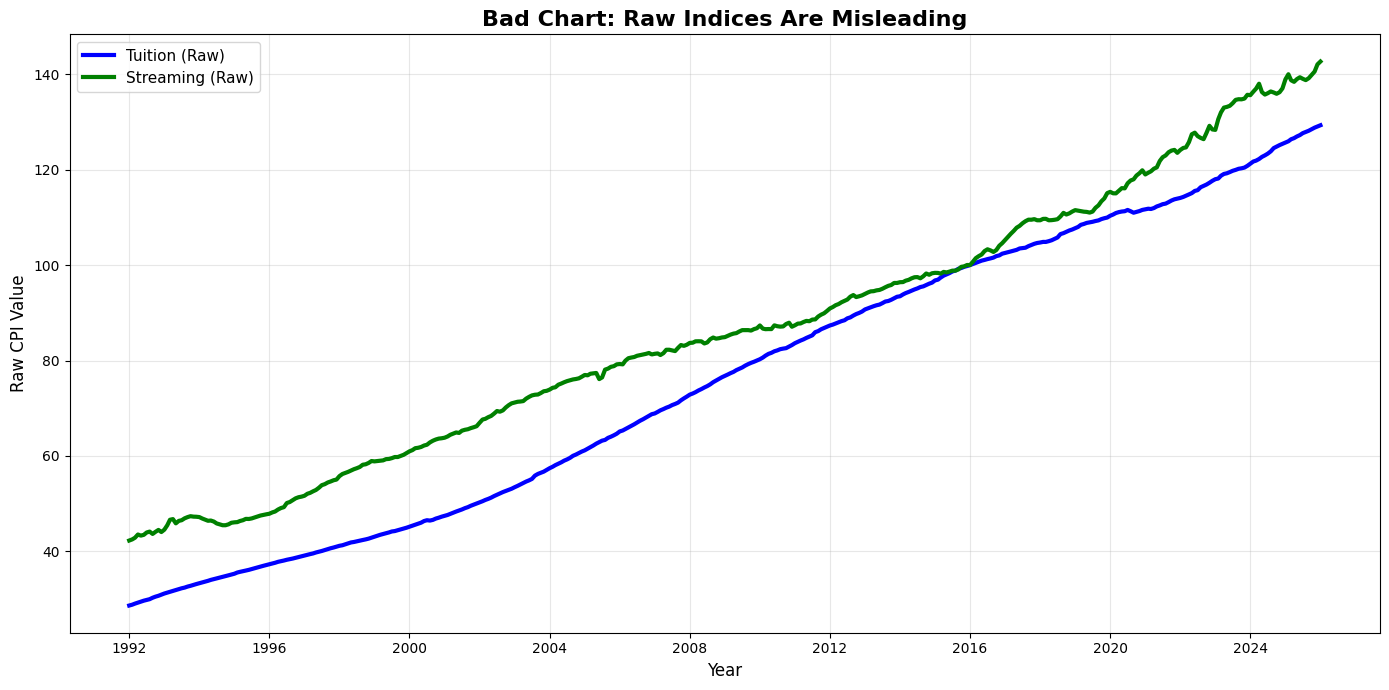

In [34]:
# Create figure and axis
fig, ax = plt.subplots(figsize=(14, 7))

# Plot the RAW tuition data
ax.plot(df.index, df['Tuition'],
        linestyle='-',
        color='blue',
        linewidth=3,
        label='Tuition (Raw)')

# Plot the RAW streaming data
ax.plot(df.index, df['Spotify'],
        linestyle='-',
        color='green',
        linewidth=3,
        label='Streaming (Raw)')

# Add titles
ax.set_title('Bad Chart: Raw Indices Are Misleading',
             fontsize=16,
             fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Raw CPI Value', fontsize=12)

# Add legend
ax.legend(loc='best', fontsize=11)

# Add grid for better readability
ax.grid(True, alpha=0.3)

# Adjust layout
plt.tight_layout()

# Display the plot
plt.show()

Why comparing raw indices with different base years (e.g., 1982 vs 2002) is a "Data Crime.":

Observation:Tuition is around ~900+. Streaming is ~100, looks like Tuition is "huge" and Streaming is "tiny."

Comparing the two line, streaming line looks flat whereas the tuition line looks dominant, this was due to that tuition CPI is indexed to an earlier base year (1982 = 100), while Streaming CPI uses a later base year (2002 = 100). Because the indices are measured on different scales, plotting them together creates the illusion that tuition costs are “huge” and streaming costs are “negligible,” even though the numeric difference reflects indexing conventions rather than true relative price growth. Without normalization, visual comparisons across categories constitute a form of data misuse, also indicatin that comparing raw indices with different base years is meaningless.


Fetching Boston-Cambridge-Newton CPI from FRED...
Boston CPI data fetched!
2025-05-01    347.897
2025-07-01    346.856
2025-09-01    349.271
2025-11-01    347.892
2026-01-01    348.343
dtype: float64

Boston CPI normalized to 2016 = 100:
Value at 2016-01-01: 100.00
Latest value: 135.43


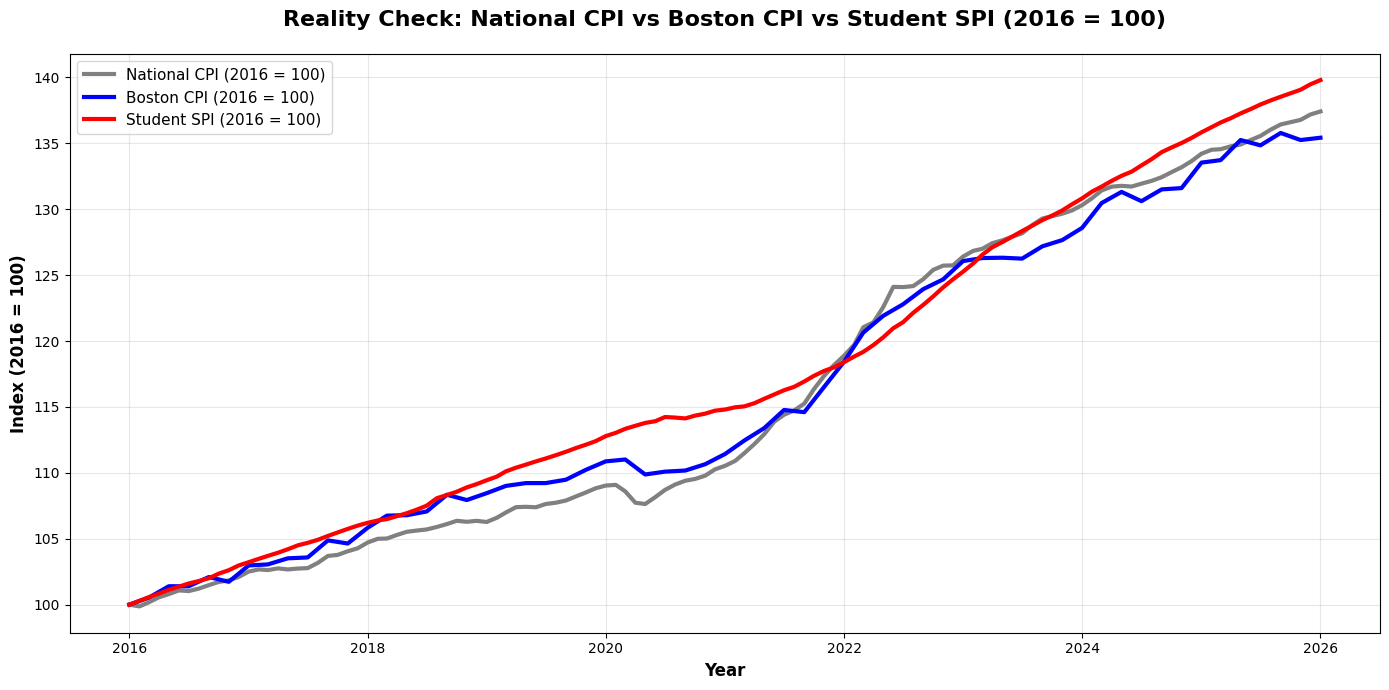


FINAL COMPARISON (Index: 2016 = 100)
National CPI (Latest): 137.42
Boston CPI (Latest):   135.43
Student SPI (Latest):  139.80


In [28]:
# ============================================
# TASK 4.1: Boston vs USA vs You
# ============================================

# Fetch Boston CPI
print("Fetching Boston-Cambridge-Newton CPI from FRED...")
boston_cpi = fred.get_series('CUURA103SA0')

# Drop NaN values
boston_cpi = boston_cpi.dropna()

print("Boston CPI data fetched!")
print(boston_cpi.tail())

# Normalize Boston CPI to 2016 = 100
start_date = '2016-01-01'
boston_normalized = (boston_cpi / boston_cpi.loc[start_date]) * 100

print("\nBoston CPI normalized to 2016 = 100:")
print(f"Value at 2016-01-01: {boston_normalized.loc[start_date]:.2f}")
print(f"Latest value: {boston_normalized.iloc[-1]:.2f}")

# Filter data to 2016 onwards for cleaner visualization
start_plot = '2016-01-01'

# Create figure and axis
fig, ax = plt.subplots(figsize=(14, 7))

# Plot 1: National CPI (Grey)
ax.plot(Value_Index.loc[start_plot:].index, Value_Index.loc[start_plot:]['Official_CPI'],
        linestyle='-',
        color='grey',
        linewidth=3,
        label='National CPI (2016 = 100)')

# Plot 2: Boston CPI (Blue)
ax.plot(boston_normalized.loc[start_plot:].index, boston_normalized.loc[start_plot:],
        linestyle='-',
        color='blue',
        linewidth=3,
        label='Boston CPI (2016 = 100)')

# Plot 3: Student SPI (Red)
ax.plot(df.loc[start_plot:].index, df.loc[start_plot:]['Student_SPI'],
        linestyle='-',
        color='red',
        linewidth=3,
        label='Student SPI (2016 = 100)')

# Add title and labels
ax.set_title('Reality Check: National CPI vs Boston CPI vs Student SPI (2016 = 100)',
             fontsize=16,
             fontweight='bold',
             pad=20)
ax.set_xlabel('Year', fontsize=12, fontweight='bold')
ax.set_ylabel('Index (2016 = 100)', fontsize=12, fontweight='bold')

# Add legend
ax.legend(loc='best', fontsize=11, frameon=True)

# Add grid
ax.grid(True, alpha=0.3)

# Adjust layout
plt.tight_layout()

# Display the plot
plt.show()

# Print final comparison
print("\n" + "="*60)
print("FINAL COMPARISON (Index: 2016 = 100)")
print("="*60)
print(f"National CPI (Latest): {Value_Index['Official_CPI'].iloc[-1]:.2f}")
print(f"Boston CPI (Latest):   {boston_normalized.iloc[-1]:.2f}")
print(f"Student SPI (Latest):  {df['Student_SPI'].iloc[-1]:.2f}")
print("="*60)